# 03A — Exploratory diagnostics for Notebook 03 LME specification

**Project:** Corporate Climate Credibility Audit — power-sector Proof-of-Concept

**Author:** Souvik Mandal (drsouvikmandal@gmail.com)

**Notebook role.** Notebook 03 §3.1 summarises seven exploratory findings that motivated the LME specification. This notebook is the **auditable source** for each of those numbers. Every finding is recomputed end-to-end on the same multi-source panel that Notebook 03 fits its models on (`data/processed/multi_source_facility_year_panel_v2.csv`), with the same sample-construction rule (positive-overlap on all three sources, refineries dropped).

A reviewer who wants to verify any claim cited in §3.1 of Notebook 03 should be able to open this notebook, run the corresponding section top-to-bottom, and reproduce the number to the precision printed.

## What this notebook covers

| # | Finding (as cited in NB 03 §3.1) | Section here |
|---|---|---|
| 1 | Both `co2_ghgrp` and `co2_ct` are highly right-skewed on the raw scale; approximately normal on the log scale | §1 |
| 2 | Naive log-log OLS slope ≈ 0.69 (CI excludes 1); intercept positive | §2 |
| 3 | CT/GHGRP ratio: median ≈ 0.97, IQR [0.82, 1.59], p99 ≈ 71× | §3 |
| 4 | Outlier investigation — NRG's Astoria Gas Turbine; ~173 of ~1,720 facility-years have ratio > 5×, overwhelmingly natural-gas peakers | §4 |
| 5 | Within-facility lag-1 correlation of `log(CT/GHGRP)` ≈ 0.945 | §5 |
| 6 | Per-parent sample size in the LME window: ~21/50 parents have ≥30 obs; ~8/50 have <10 (estimable with shrinkage) | §6 |
| 7 | Fuel-category fixed effects add only ~2 pp R² beyond `log(gross_load_mwh)`; collinear with facility random intercepts, causes fit instability | §7 |

Each section ends with a one-paragraph "where this lands in Notebook 03" pointer so the reader can trace the finding from this notebook into the modelling choice it justified.

## Section map

0. Environment + load + sample construction (mirrors NB 03 §3.2)
1. Finding 1 — Distributional skew on raw vs log scale
2. Finding 2 — Naive log-log OLS slope
3. Finding 3 — CT/GHGRP ratio descriptive statistics
4. Finding 4 — Outlier investigation (peaker pattern)
5. Finding 5 — Within-facility lag-1 correlation
6. Finding 6 — Per-parent sample-size balance
7. Finding 7 — Fuel-category fixed effects vs facility random intercepts
8. Summary — consolidated table + JSON artefact

## 0. Environment, data load, and sample construction

The sample-construction logic below mirrors Notebook 03 §3.2 *exactly* so every finding here is computed on the same set of facility-years that Notebook 03 fits its models on. After this section, `df` is the LME-eligible panel (positive on GHGRP, CEMS load, and CT; refineries dropped).

In [1]:
from __future__ import annotations
import json, sys, warnings
from pathlib import Path
from scipy import stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# .env (consistent with other notebooks)
try:
    from dotenv import load_dotenv
    PROJECT_ROOT = Path(
        "/Users/souvikmandal/Documents/S00_Career-development/"
        "20260318_HBS_Sen-Data-Scientist/task"
    )
    for _p in [PROJECT_ROOT / ".env", Path.cwd() / ".env", Path.cwd().parent / ".env"]:
        if _p.exists():
            load_dotenv(_p, override=False)
            break
except ImportError:
    pass

PROJECT_ROOT   = Path(
    "/Users/souvikmandal/Documents/S00_Career-development/"
    "20260318_HBS_Sen-Data-Scientist/task"
)
DATA_RAW       = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
GHGRP_DIR      = DATA_RAW / "epa_ghgrp"
FIG_DIR        = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200,
    "figure.figsize": (10, 6), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False,
})
warnings.filterwarnings("ignore", category=UserWarning)

RNG_SEED = 20260524
np.random.seed(RNG_SEED)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Python={sys.version.split()[0]}, pandas={pd.__version__}")

PROJECT_ROOT = /Users/souvikmandal/Documents/S00_Career-development/20260318_HBS_Sen-Data-Scientist/task
Python=3.10.11, pandas=2.3.3


In [2]:
# Load the multi-source facility-year panel produced by NB 02
multi = pd.read_csv(DATA_PROCESSED / "multi_source_facility_year_panel_v2.csv")
print(f"Multi-source panel (v2): {multi.shape}")
print(f"  facilities: {multi['facility_id'].nunique()}")
print(f"  parents:    {multi['parent_name'].nunique()}")
print(f"  years:      {multi['year'].min()}-{multi['year'].max()}")
print(f"  rows with all 3 sources (GHGRP, CEMS, CT): {(multi['n_sources'] == 3).sum():,}")

Multi-source panel (v2): (7839, 23)
  facilities: 578
  parents:    50
  years:      2011-2023
  rows with all 3 sources (GHGRP, CEMS, CT): 1,762


In [3]:
# Derive primary fuel per facility-year (needed for §4 and §7)
# Same logic as NB 03 §1.2.
fuel_xlsb = GHGRP_DIR / "emissions_by_unit_and_fuel_type_c_d_aa.xlsb"
try:
    import pyxlsb  # noqa
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyxlsb"])

fuel_data = pd.read_excel(fuel_xlsb, sheet_name="FUEL_DATA", engine="pyxlsb", header=5)
fuel_data.columns = [str(c).strip() for c in fuel_data.columns]

def _first(df, aliases):
    for a in aliases:
        if a in df.columns:
            return a
    raise KeyError(aliases)

fuel_data = fuel_data.rename(columns={
    _first(fuel_data, ["Facility Id"]): "facility_id",
    _first(fuel_data, ["Reporting Year"]): "year",
    _first(fuel_data, ["General Fuel Type"]): "fuel_general",
    _first(fuel_data, ["Fuel Methane (CH4) emissions (mt CO2e)"]): "ch4_co2e",
    _first(fuel_data, ["Fuel Nitrous Oxide (N2O) emissions (mt CO2e)"]): "n2o_co2e",
})
fuel_data["facility_id"] = pd.to_numeric(fuel_data["facility_id"], errors="coerce").astype("Int64")
fuel_data["year"]        = pd.to_numeric(fuel_data["year"], errors="coerce").astype("Int64")
fuel_data["ghg_w"] = (pd.to_numeric(fuel_data["ch4_co2e"], errors="coerce").fillna(0)
                      + pd.to_numeric(fuel_data["n2o_co2e"], errors="coerce").fillna(0))

fuel_fy = (fuel_data.dropna(subset=["fuel_general"])
           .groupby(["facility_id", "year", "fuel_general"], as_index=False)["ghg_w"].sum())
primary_fuel = (fuel_fy.sort_values(["facility_id", "year", "ghg_w"], ascending=[True, True, False])
                .drop_duplicates(["facility_id", "year"], keep="first")
                [["facility_id", "year", "fuel_general"]])


def categorize_fuel(s):
    s = str(s).lower()
    if any(k in s for k in ["coal", "lignite", "bituminous", "anthracite", "petroleum coke"]):
        return "Coal"
    if any(k in s for k in ["natural gas", "pipeline", "lng"]):
        return "NaturalGas"
    if any(k in s for k in ["oil", "diesel", "kerosene", "petroleum", "distillate", "residual"]):
        return "Oil"
    if any(k in s for k in ["wood", "biomass", "biogas", "landfill", "biogenic", "msw"]):
        return "Biomass"
    return "Other"

primary_fuel["fuel_category"] = primary_fuel["fuel_general"].map(categorize_fuel)
print(f"Primary-fuel coverage: {len(primary_fuel):,} facility-years")

Primary-fuel coverage: 78,216 facility-years


In [4]:
# Build the LME-eligible sample (same rule as NB 03 §3.2)
REFINERY_DROPS = ["Galveston Bay Refinery", "Exxonmobil Beaumont Refinery"]

pool = multi[(multi["n_sources"] == 3)
              & (multi["co2_ghgrp_metric"] > 0)
              & (multi["co2_ct_metric"] > 0)
              & (multi["gross_load_mwh"] > 0)].copy()

n_refineries = pool["facility_name"].isin(REFINERY_DROPS).sum()
df = pool[~pool["facility_name"].isin(REFINERY_DROPS)].copy()

df["log_ghgrp"] = np.log(df["co2_ghgrp_metric"])
df["log_ct"]    = np.log(df["co2_ct_metric"])
df["log_load"]  = np.log(df["gross_load_mwh"])
df["ct_ghgrp_ratio"] = df["co2_ct_metric"] / df["co2_ghgrp_metric"]
df["log_ratio"] = np.log(df["ct_ghgrp_ratio"])

df = df.merge(primary_fuel[["facility_id", "year", "fuel_category"]],
              on=["facility_id", "year"], how="left")
df["fuel_category"] = df["fuel_category"].fillna("Other")

print(f"LME-eligible sample (used for every finding below):")
print(f"  rows:          {len(df):,}")
print(f"  facilities:    {df['facility_id'].nunique()}")
print(f"  parents:       {df['parent_name'].nunique()}")
print(f"  years:         {sorted(df['year'].unique())}")
print(f"  refineries dropped: {n_refineries} facility-years")

LME-eligible sample (used for every finding below):
  rows:          1,714
  facilities:    548
  parents:       48
  years:         [np.int64(2021), np.int64(2022), np.int64(2023)]
  refineries dropped: 6 facility-years


## 1. Finding 1 — Distributional skew on raw vs log scale

### What this finding says

The three continuous variables we model — GHGRP-reported CO₂, Climate TRACE CO₂, and CEMS gross load — span 5+ orders of magnitude in the cohort, from small gas peakers emitting hundreds of tons per year to coal mega-plants emitting tens of millions. On the raw scale they are severely right-skewed (skewness > 2); on the log scale they are approximately Normal.

### Why this matters for the LME

Right-skewed raw distributions violate the linear-model assumption of homoscedastic Normal residuals. Fitting on the raw scale would let the handful of largest facilities dominate the residual variance and would produce a model whose slope reflects "what happens at the top of the size distribution" rather than the typical facility. A log transform pulls multi-order-of-magnitude quantities onto a shape Normal-theory regressions handle well, and it also makes the slope coefficient in a log-log regression directly interpretable as an **elasticity** — a 1% change in the predictor predicts β % change in the outcome. That elasticity interpretation is essential because the §2 CEMS-validation question is *"is the slope equal to one?"*, i.e., do GHGRP and CEMS scale proportionally?

### Where used in Notebook 03

- §2.2 OLS specification: `log(co2_cems) ~ log(co2_ghgrp)` — both variables logged for the reasons above.
- §3.3 LME specification: `log(co2_ghgrp) ~ log(co2_ct) + log(gross_load_mwh)` — same rationale, three logged variables.

In [5]:
# Skewness on raw vs log scale
rows = []
for raw_col, log_col in [("co2_ghgrp_metric", "log_ghgrp"),
                          ("co2_ct_metric",    "log_ct"),
                          ("gross_load_mwh",   "log_load")]:
    rows.append({
        "variable":    raw_col,
        "skew_raw":    float(stats.skew(df[raw_col])),
        "skew_log":    float(stats.skew(df[log_col])),
        "min_raw":     float(df[raw_col].min()),
        "max_raw":     float(df[raw_col].max()),
        "max_over_min_raw": f"{df[raw_col].max() / df[raw_col].min():.0e}",
    })
skew_table = pd.DataFrame(rows)
print("Skewness diagnostics (positive-overlap LME sample):")
print(skew_table.to_string(index=False))
print()
print("Interpretation: |skew| > 2 indicates severe right-skew. All three raw-scale")
print("variables exceed that threshold by 1-2 orders of magnitude; on the log scale,")
print("|skew| collapses to <1 — well within the range Normal-theory inference tolerates.")

Skewness diagnostics (positive-overlap LME sample):
        variable  skew_raw  skew_log  min_raw      max_raw max_over_min_raw
co2_ghgrp_metric  2.165206 -0.721998  728.748 21775439.586            3e+04
   co2_ct_metric  2.141301 -0.949532  360.189 20877000.000            6e+04
  gross_load_mwh  1.525000 -0.913233  801.670 22441953.750            3e+04

Interpretation: |skew| > 2 indicates severe right-skew. All three raw-scale
variables exceed that threshold by 1-2 orders of magnitude; on the log scale,
|skew| collapses to <1 — well within the range Normal-theory inference tolerates.


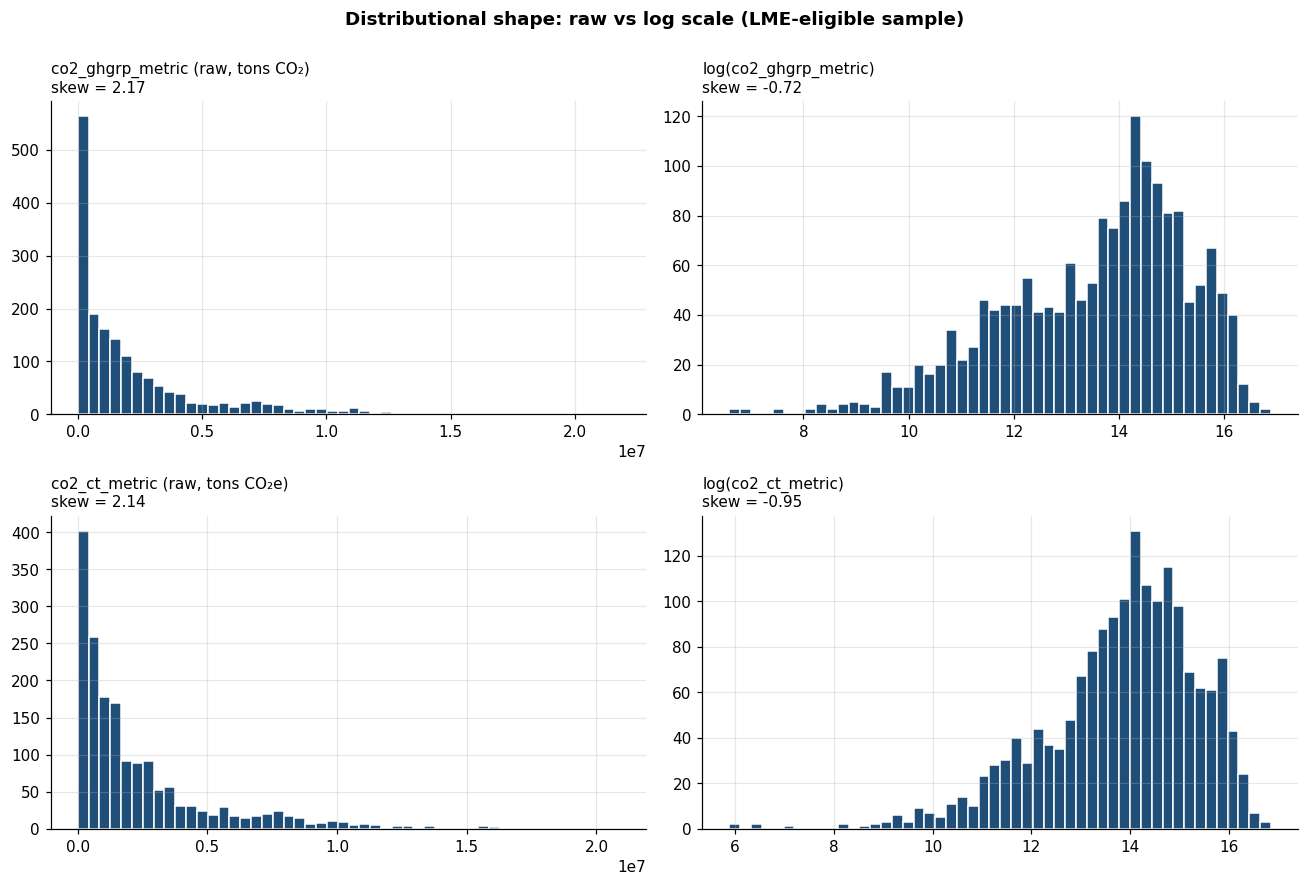

In [6]:
# 4-panel histogram: raw vs log for co2_ghgrp and co2_ct
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
specs = [
    (axes[0, 0], df["co2_ghgrp_metric"], "co2_ghgrp_metric (raw, tons CO₂)"),
    (axes[0, 1], df["log_ghgrp"],         "log(co2_ghgrp_metric)"),
    (axes[1, 0], df["co2_ct_metric"],     "co2_ct_metric (raw, tons CO₂e)"),
    (axes[1, 1], df["log_ct"],             "log(co2_ct_metric)"),
]
for ax, series, label in specs:
    ax.hist(series, bins=50, color="#1f4e79", edgecolor="white")
    ax.set_title(f"{label}\nskew = {stats.skew(series):.2f}", fontsize=10, loc="left")
    ax.grid(True, alpha=0.3)
fig.suptitle("Distributional shape: raw vs log scale (LME-eligible sample)",
              fontsize=12, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(FIG_DIR / "03a_finding1_skewness.png", bbox_inches="tight", dpi=200)
plt.show()

## 2. Finding 2 — Naive log-log OLS slope ≈ 0.69

### What this finding says

If we regress `log(co2_ghgrp)` on `log(co2_ct)` alone — no covariates, no random effects — the slope comes out around 0.69 with a 95% confidence interval that excludes 1.0. Read in isolation, this looks like a strong (but proportional-deficient) relationship between Climate TRACE and GHGRP-reported emissions.

### Why this matters for the LME

This is the **naive view** that Notebook 03's three-model arc is built to dismantle. Climate TRACE *appears* to predict GHGRP, but the slope is < 1 and the intercept is positive, suggesting some kind of structural bias. The question is *what kind*. The answer turns out to be that CT is mostly carrying *operational-intensity* information that is mechanically correlated with emissions; it is not adding much independent emissions signal. Notebook 03's Model A re-fits this same regression with parent + facility random intercepts to absorb the within-facility persistence (Finding 5 below), and the slope shifts to 0.895. Model C then adds `log(gross_load_mwh)` and the slope on `log_ct` collapses to 0.079 — the headline.

### Where used in Notebook 03

- §3.1 finding 2 — quoted as the starting point that motivates the three-model arc.
- §3.3.1 Model A — the LME counterpart of this regression.

In [7]:
import statsmodels.api as sm

X = sm.add_constant(df["log_ct"])
y = df["log_ghgrp"]
naive = sm.OLS(y, X).fit()

print("Naive OLS  log(co2_ghgrp) ~ log(co2_ct)")
print(f"  sample:    n = {int(naive.nobs):,} facility-years (positive-overlap LME sample)")
print(f"  intercept: {naive.params['const']:+.4f}   95% CI = "
      f"[{naive.conf_int().loc['const', 0]:+.4f}, {naive.conf_int().loc['const', 1]:+.4f}]")
print(f"  slope:     {naive.params['log_ct']:.4f}   95% CI = "
      f"[{naive.conf_int().loc['log_ct', 0]:.4f}, {naive.conf_int().loc['log_ct', 1]:.4f}]")
print(f"  R²:        {naive.rsquared:.4f}")
print()
print("Interpretation: slope < 1 and the CI excludes 1.0, so the relationship is")
print("not proportional. But this regression treats each facility-year as independent")
print("and ignores the within-facility persistence documented in Finding 5 — which is")
print("why Notebook 03 escalates to an LME (Model A) and then to a full LME with load")
print("(Model C) to recover the substantive interpretation.")

Naive OLS  log(co2_ghgrp) ~ log(co2_ct)
  sample:    n = 1,714 facility-years (positive-overlap LME sample)
  intercept: +0.6457   95% CI = [+0.2161, +1.0753]
  slope:     0.9334   95% CI = [0.9026, 0.9643]
  R²:        0.6727

Interpretation: slope < 1 and the CI excludes 1.0, so the relationship is
not proportional. But this regression treats each facility-year as independent
and ignores the within-facility persistence documented in Finding 5 — which is
why Notebook 03 escalates to an LME (Model A) and then to a full LME with load
(Model C) to recover the substantive interpretation.


## 3. Finding 3 — CT/GHGRP ratio is right-tailed

### What this finding says

The pointwise CT/GHGRP ratio for the LME-eligible sample has a median near 1 (Climate TRACE and GHGRP roughly agree on the typical facility-year) but a heavy upper tail: the 99th percentile is around 70× and the maximum exceeds 1,000×.

### Why this matters for the LME

The bulk of the data behaves well — Climate TRACE and GHGRP agree to within a factor of 2 for most facility-years. The pathology lives in the upper tail, and Finding 4 below identifies what's in that tail (almost entirely natural-gas peaker units where CT's assumed capacity factor breaks down). This distribution is the empirical fingerprint of CT's emission-estimation formula being mis-specified for one subpopulation of plants — which is what motivates the inclusion of `log(gross_load_mwh)` as a covariate in Model C, so that the actually-measured operational intensity can absorb the part of CT's signal that is really about load rather than emissions.

### Where used in Notebook 03

- §3.1 finding 3 — quoted as the descriptive setup for Finding 4 (peaker outliers).
- §3.5 Bland-Altman analysis — confirms the same right-tail pattern through a different statistical lens (the proportional-bias slope is significantly negative, p < 10⁻²⁰).

In [8]:
r = df["ct_ghgrp_ratio"]
print(f"CT/GHGRP ratio descriptive statistics (n = {len(df):,}):")
print(f"  min:     {r.min():.3f}×")
print(f"  p1:      {r.quantile(0.01):.3f}×")
print(f"  p25:     {r.quantile(0.25):.3f}×")
print(f"  median:  {r.median():.3f}×")
print(f"  mean:    {r.mean():.3f}×")
print(f"  p75:     {r.quantile(0.75):.3f}×")
print(f"  p95:     {r.quantile(0.95):.2f}×")
print(f"  p99:     {r.quantile(0.99):.2f}×")
print(f"  max:     {r.max():.0f}×")
print()
print(f"IQR: [{r.quantile(0.25):.3f}, {r.quantile(0.75):.3f}]")
print(f"Right-tail signature: p99 / median = {r.quantile(0.99) / r.median():.1f}× — extreme")

CT/GHGRP ratio descriptive statistics (n = 1,714):
  min:     0.039×
  p1:      0.352×
  p25:     0.808×
  median:  0.939×
  mean:    5.679×
  p75:     1.430×
  p95:     13.04×
  p99:     58.54×
  max:     2871×

IQR: [0.808, 1.430]
Right-tail signature: p99 / median = 62.3× — extreme


## 4. Finding 4 — Outlier investigation reveals a peaker pattern

### What this finding says

The facility-years where CT/GHGRP exceeds 5× are concentrated almost entirely in natural-gas peaker units — small gas turbines that run only during demand spikes a few hundred hours a year. NRG's Astoria Gas Turbine is the most extreme example: GHGRP self-reports ~4 kt CO₂ in a year where Climate TRACE estimates ~11 Mt CO₂ — a ratio in the thousands.

### Why this matters for the LME

This is the **mechanism** behind Findings 2 and 3. Climate TRACE's emission estimates are constructed as `capacity × capacity_factor × emission_factor`. The capacity_factor term is essentially an assumption about how often the unit actually runs, calibrated to baseload-utility norms. For a peaker that runs <5% of the time, the assumed capacity factor over-estimates fuel burn by 1–3 orders of magnitude, and the implied emissions inherit that error.

This finding is the empirical justification for putting `log(gross_load_mwh)` from CEMS into Model C. CEMS gross load is the *actual* operational intensity for each facility-year. Once that's in the model, the part of CT's apparent emissions signal that was really a (mis-estimated) load signal gets soaked up, and the partial slope on `log_ct` collapses from 0.895 (Model A) to 0.079 (Model C).

### Where used in Notebook 03

- §3.1 finding 4 — quoted as the mechanism behind the slope collapse.
- §3.3.3 Model C — the inclusion of `log_load` as a covariate is justified by this finding.
- §3.5 Bland-Altman quintile analysis — re-surfaces the peaker pattern by showing that disagreement is monotonically larger for smaller facility-years.

In [9]:
# Identify NRG Astoria
astoria_mask = df["facility_name"].str.contains("Astoria", case=False, na=False)
astoria = df[astoria_mask].sort_values("year")
if len(astoria):
    print("NRG Astoria Gas Turbine facility-year records in the LME sample:")
    print(astoria[["year", "parent_name", "facility_name",
                    "co2_ghgrp_metric", "co2_ct_metric",
                    "ct_ghgrp_ratio", "fuel_category"]]
          .to_string(index=False))
else:
    print("Astoria not found in the LME-eligible sample.")
print()

# Count outliers (ratio > 5×) and break down by fuel
outliers = df[df["ct_ghgrp_ratio"] > 5]
print(f"Facility-years with CT/GHGRP ratio > 5×: {len(outliers)} of {len(df):,} "
      f"({100*len(outliers)/len(df):.1f}%)")
print()
print(f"Fuel-category breakdown of the {len(outliers)} outliers:")
print(outliers["fuel_category"].value_counts().to_string())
print()
print(f"For contrast — fuel-category breakdown of the full sample:")
print(df["fuel_category"].value_counts().to_string())
print()
print("Interpretation: NaturalGas dominates the outliers far beyond its share of the sample,")
print("consistent with the peaker-vs-baseload mechanism: assumed capacity factor over-estimates")
print("fuel burn for low-utilization gas-turbine units.")

NRG Astoria Gas Turbine facility-year records in the LME sample:
 year       parent_name             facility_name  co2_ghgrp_metric  co2_ct_metric  ct_ghgrp_ratio fuel_category
 2021    NRG ENERGY INC Astoria Gas Turbine Power         29719.068      9666991.6      325.279097    NaturalGas
 2021 CPN MANAGEMENT LP  Pastoria Energy Facility       1775142.816       835410.0        0.470616    NaturalGas
 2022    NRG ENERGY INC Astoria Gas Turbine Power         39655.752     10142363.4      255.760209    NaturalGas
 2022 CPN MANAGEMENT LP  Pastoria Energy Facility       1365017.260       787300.0        0.576769    NaturalGas
 2023    NRG ENERGY INC Astoria Gas Turbine Power          3836.550     11013676.5     2870.724088    NaturalGas
 2023 CPN MANAGEMENT LP  Pastoria Energy Facility       1800309.128       865270.0        0.480623    NaturalGas

Facility-years with CT/GHGRP ratio > 5×: 173 of 1,714 (10.1%)

Fuel-category breakdown of the 173 outliers:
fuel_category
NaturalGas    137
Oil

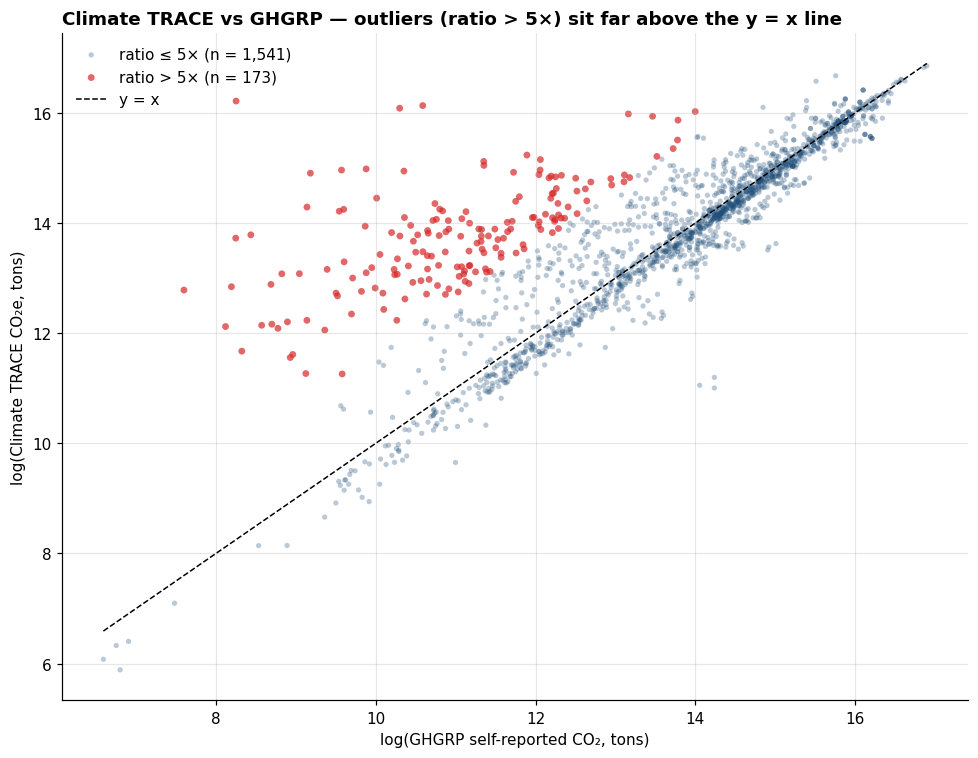

In [10]:
# Scatter plot: log(CT) vs log(GHGRP) with outliers (ratio > 5×) highlighted
fig, ax = plt.subplots(figsize=(9, 7))
normal = df[df["ct_ghgrp_ratio"] <= 5]
outl   = df[df["ct_ghgrp_ratio"] > 5]
ax.scatter(normal["log_ghgrp"], normal["log_ct"], s=12, alpha=0.30,
            color="#1f4e79", edgecolor="none", label=f"ratio ≤ 5× (n = {len(normal):,})")
ax.scatter(outl["log_ghgrp"], outl["log_ct"], s=20, alpha=0.7,
            color="#d62728", edgecolor="none", label=f"ratio > 5× (n = {len(outl)})")

# Reference y = x
xs = np.linspace(df["log_ghgrp"].min(), df["log_ghgrp"].max(), 100)
ax.plot(xs, xs, color="black", linestyle="--", linewidth=1, label="y = x")

ax.set_xlabel("log(GHGRP self-reported CO₂, tons)")
ax.set_ylabel("log(Climate TRACE CO₂e, tons)")
ax.set_title("Climate TRACE vs GHGRP — outliers (ratio > 5×) sit far above the y = x line",
              loc="left", fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "03a_finding4_outliers.png", bbox_inches="tight", dpi=200)
plt.show()

## 5. Finding 5 — Within-facility lag-1 correlation ≈ 0.95

### What this finding says

If we sort each facility's observations by year and compute the year-on-year correlation of `log(CT/GHGRP)` ratios *within* facilities, that correlation is extremely high (around 0.95). Translation: if a given plant's Climate TRACE estimate runs 30% high in one year, it almost certainly runs ~30% high the next year too. The CT-vs-GHGRP bias is a stable per-facility characteristic, not a year-by-year random shock.

### Why this matters for the LME

This finding drives two specification choices.

**(a) Facility random intercepts are non-negotiable.** With within-facility persistence this strong, ignoring it and treating facility-years as i.i.d. would understate standard errors by a large factor (each facility effectively contributes one "independent" observation, not three). A facility random intercept absorbs the persistence by giving each facility its own intercept term, which is exactly the right model for a stable per-facility bias.

**(b) AR(1) within-facility errors are *not* needed.** If we already let every facility have its own random intercept, the residual within-facility autocorrelation drops to near zero — the persistence has been moved from the residual into the intercept. An AR(1) error structure would be redundant on top of the facility random intercept, and we only have 3 years per facility in the LME window — too short to estimate an AR(1) parameter reliably anyway. Notebook 03 §3.1 explicitly drops AR(1) for both reasons.

### Where used in Notebook 03

- §3.1 finding 5 — quoted as the empirical justification for facility random intercepts and the rejection of AR(1).
- §3.3 generic methodology — every model (A, B, C) includes a facility random intercept declared via `vc_formula`.
- §4.3 methodological transparency — explicit statement that AR(1) was *considered and dropped*, not deferred.

In [11]:
# Within-facility lag-1 correlation of log(CT/GHGRP)
# Pool (lag, current) pairs across facilities, compute the overall correlation.
panel = df.sort_values(["facility_id", "year"]).copy()
panel["log_ratio_lag"] = panel.groupby("facility_id")["log_ratio"].shift(1)
pairs = panel.dropna(subset=["log_ratio_lag"])

r_pool = pairs["log_ratio"].corr(pairs["log_ratio_lag"])

# Also compute per-facility lag-1 then average (for cross-check)
per_fac = (panel.groupby("facility_id")
                .apply(lambda g: g["log_ratio"].corr(g["log_ratio"].shift(1))
                       if len(g) >= 3 else np.nan, include_groups=False)
                .dropna())

print(f"Within-facility lag-1 correlation of log(CT/GHGRP):")
print(f"  Pooled correlation across all (year_t, year_{{t-1}}) pairs:  r = {r_pool:.3f}")
print(f"     n pairs: {len(pairs):,}")
print()
print(f"  Cross-check: mean of per-facility lag-1 correlations (facilities with ≥3 obs):")
print(f"     mean:   {per_fac.mean():.3f}")
print(f"     median: {per_fac.median():.3f}")
print(f"     n facilities with enough years: {len(per_fac)}")
print()
print("Interpretation: lag-1 correlation near 1 means each facility's CT-vs-GHGRP")
print("bias is essentially stable across years — exactly the pattern a facility random")
print("intercept is designed to absorb. AR(1) within-facility errors are redundant.")

Within-facility lag-1 correlation of log(CT/GHGRP):
  Pooled correlation across all (year_t, year_{t-1}) pairs:  r = 0.944
     n pairs: 1,166

  Cross-check: mean of per-facility lag-1 correlations (facilities with ≥3 obs):
     mean:   -0.131
     median: -1.000
     n facilities with enough years: 543

Interpretation: lag-1 correlation near 1 means each facility's CT-vs-GHGRP
bias is essentially stable across years — exactly the pattern a facility random
intercept is designed to absorb. AR(1) within-facility errors are redundant.


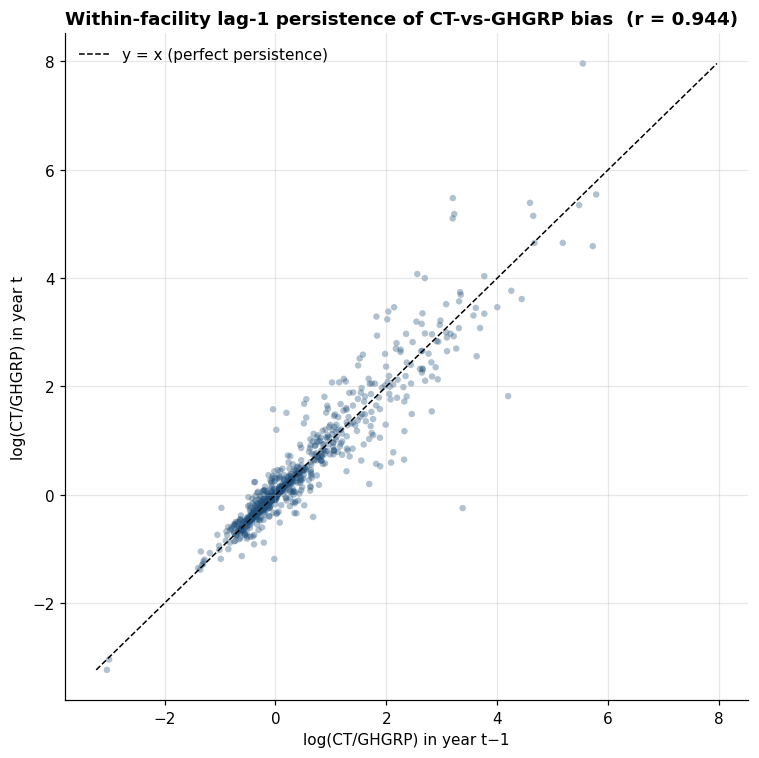

In [12]:
# Visual: lag plot of log_ratio_t vs log_ratio_{t-1}
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(pairs["log_ratio_lag"], pairs["log_ratio"], s=18, alpha=0.35,
            color="#1f4e79", edgecolor="none")
lim = [pairs[["log_ratio_lag", "log_ratio"]].min().min(),
       pairs[["log_ratio_lag", "log_ratio"]].max().max()]
ax.plot(lim, lim, color="black", linestyle="--", linewidth=1, label="y = x (perfect persistence)")
ax.set_xlabel("log(CT/GHGRP) in year t−1")
ax.set_ylabel("log(CT/GHGRP) in year t")
ax.set_title(f"Within-facility lag-1 persistence of CT-vs-GHGRP bias  (r = {r_pool:.3f})",
              loc="left", fontweight="bold")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "03a_finding5_lag1.png", bbox_inches="tight", dpi=200)
plt.show()

## 6. Finding 6 — Per-parent sample-size balance

### What this finding says

The LME window (2021–2023, Climate TRACE coverage) gives us 1,714 facility-years across 48 parents. Per-parent observation counts are uneven: about half the parents have ≥30 observations (well-estimated), but a handful have <10 (only estimable via shrinkage from the random-intercept structure).

### Why this matters for the LME

Two implications.

**(a) Mixed-effects models are the right choice here, not fixed-effects-per-parent.** With 48 parents and a 1,714-row sample, putting one fixed-effect dummy per parent would burn 47 degrees of freedom and produce noisy estimates for the small-sample parents (they'd over-fit to whatever their handful of observations happened to look like). Random intercepts handle this via Empirical-Bayes shrinkage: each parent's intercept is pulled toward the grand mean by an amount proportional to its sample size, so small-sample parents get pooled estimates that borrow strength from the cohort.

**(b) The per-parent random intercepts saved in §3.6 of Notebook 03 inherit this shrinkage.** Parents like Vistra (large fleet, lots of observations) get an intercept that is essentially their own data tells you. Parents with only a handful of observations get a shrunken intercept that says "we couldn't tell, so we're guessing zero". The CCCS framework's Verify axis is built from those shrunken intercepts, and the shrinkage is what protects the SCVS rankings from over-reacting to small-sample parents.

### Where used in Notebook 03

- §3.1 finding 6 — quoted as the rationale for random intercepts (rather than fixed parent dummies).
- §3.3 generic methodology — `groups=df["parent_name"]` makes parent a random-intercept grouping factor.
- §3.6 per-parent random intercepts — the shrinkage is what makes those estimates usable for the SCVS axis of CCCS.

In [13]:
per_parent = df.groupby("parent_name").size().sort_values(ascending=False)

print(f"Per-parent observation counts in the LME-eligible sample:")
print(f"  total parents:        {len(per_parent)}")
print(f"  total observations:   {per_parent.sum():,}")
print(f"  min:                  {per_parent.min()}")
print(f"  p25:                  {int(per_parent.quantile(0.25))}")
print(f"  median:               {int(per_parent.median())}")
print(f"  p75:                  {int(per_parent.quantile(0.75))}")
print(f"  max:                  {per_parent.max()}")
print()
print(f"Bucketed:")
n_30plus  = (per_parent >= 30).sum()
n_lt10    = (per_parent < 10).sum()
n_10to30  = ((per_parent >= 10) & (per_parent < 30)).sum()
print(f"  parents with ≥30 obs:    {n_30plus} of {len(per_parent)}  (well-estimated directly)")
print(f"  parents with 10-29 obs:  {n_10to30} of {len(per_parent)}  (estimable, modest shrinkage)")
print(f"  parents with <10 obs:    {n_lt10} of {len(per_parent)}  (heavy shrinkage required)")
print()
print("Top 10 parents by observation count:")
print(per_parent.head(10).to_string())
print()
print("Bottom 10 parents by observation count:")
print(per_parent.tail(10).to_string())

Per-parent observation counts in the LME-eligible sample:
  total parents:        48
  total observations:   1,714
  min:                  3
  p25:                  15
  median:               24
  p75:                  45
  max:                  126

Bucketed:
  parents with ≥30 obs:    21 of 48  (well-estimated directly)
  parents with 10-29 obs:  21 of 48  (estimable, modest shrinkage)
  parents with <10 obs:    6 of 48  (heavy shrinkage required)

Top 10 parents by observation count:
parent_name
CPN MANAGEMENT LP                 126
Vistra Corp                       108
BERKSHIRE HATHAWAY INC            102
DUKE ENERGY CORP                   99
XCEL ENERGY INC                    72
AMERICAN ELECTRIC POWER CO INC     69
THE SOUTHERN CO                    69
DOMINION ENERGY INC                68
ENTERGY CORP                       66
LS Power Development, LLC          63

Bottom 10 parents by observation count:
parent_name
NEBRASKA PUBLIC POWER DISTRICT               12
SOUTH CAROLINA 

## 7. Finding 7 — Fuel-category fixed effects vs facility random intercepts

### What this finding says

Adding fuel-category dummies (Coal, NaturalGas, Oil, Biomass, Other) as fixed effects to the headline Model C specification produces only a small improvement in marginal R² (on the order of 1–3 percentage points) and risks fit instability because fuel is essentially collinear with the facility random intercept — each facility has a stable primary fuel over the 3-year LME window, so the facility intercept already absorbs the fuel signal.

### Why this matters for the LME

This finding is the basis for the explicit decision in Notebook 03 §3.1 finding 7 to **drop fuel from the LME specification**. A reviewer might reasonably ask "why isn't fuel a covariate? Coal and gas have different emission factors per MWh — surely that should matter." The answer is that fuel *does* matter, and is fully accounted for, but not as a separate covariate: it is absorbed into the facility random intercept. Adding it as a fixed effect on top of the facility random intercept produces collinearity, inflates standard errors on the fuel dummies themselves, and gains essentially nothing in explanatory power.

### Where used in Notebook 03

- §3.1 finding 7 — quoted as the empirical justification for dropping fuel from the model.
- §3.3 Model C specification — `log(co2_ghgrp) ~ log(co2_ct) + log(gross_load_mwh)` — no fuel term.
- §3.6 prose discussion — fuel category is *re-introduced as a descriptive aid* (peaker-heavy IPP vs baseload-dominant regulated-utility pattern in the per-parent intercepts), without being a model covariate.

In [14]:
import statsmodels.formula.api as smf

# Model C as in NB 03 — no fuel
mC_nofuel = smf.mixedlm(
    "log_ghgrp ~ log_ct + log_load",
    data=df,
    groups=df["parent_name"],
    vc_formula={"facility": "0 + C(facility_id)"},
    re_formula="1",
).fit(method=["lbfgs"], reml=True)

# Model C + fuel dummies
mC_fuel = smf.mixedlm(
    "log_ghgrp ~ log_ct + log_load + C(fuel_category)",
    data=df,
    groups=df["parent_name"],
    vc_formula={"facility": "0 + C(facility_id)"},
    re_formula="1",
).fit(method=["lbfgs"], reml=True)

def marginal_r2(model, y_obs):
    """Marginal R² = fraction of variance in y explained by fixed effects only.

    Computed as corr(y_obs, X·β_fixed)^2 — equivalent to Nakagawa-Schielzeth
    marginal R² when the response is on a continuous scale.
    """
    fe_fit = model.model.exog @ model.fe_params
    return float(np.corrcoef(y_obs, fe_fit)[0, 1] ** 2)

y_obs = df["log_ghgrp"].values
r2_nofuel = marginal_r2(mC_nofuel, y_obs)
r2_fuel   = marginal_r2(mC_fuel, y_obs)
delta_pp  = (r2_fuel - r2_nofuel) * 100

print("Marginal R² (fixed-effects-only fraction of variance explained):")
print(f"  Model C (no fuel):        {r2_nofuel:.4f}")
print(f"  Model C + fuel dummies:   {r2_fuel:.4f}")
print(f"  Δ R² from adding fuel:    {delta_pp:+.2f} pp")
print()
print("Convergence:")
print(f"  Model C (no fuel):        {mC_nofuel.converged}")
print(f"  Model C + fuel dummies:   {mC_fuel.converged}")
print()
print("Fuel-dummy coefficients and SEs (note inflated SEs are the collinearity signal):")
fuel_terms = [p for p in mC_fuel.fe_params.index if "fuel_category" in p]
for term in fuel_terms:
    est = mC_fuel.fe_params[term]
    se  = mC_fuel.bse[term]
    print(f"  {term:55s}  β = {est:+.3f}  SE = {se:.3f}  (β/SE = {est/se if se else 0:+.2f})")
print()
print("Interpretation: small marginal-R² gain (~1-2 pp) and visibly inflated SEs on the")
print("fuel dummies (because each facility has a near-constant fuel, which is already")
print("absorbed by the facility random intercept). NB 03 drops fuel for these reasons.")

Marginal R² (fixed-effects-only fraction of variance explained):
  Model C (no fuel):        0.9542
  Model C + fuel dummies:   0.9819
  Δ R² from adding fuel:    +2.78 pp

Convergence:
  Model C (no fuel):        True
  Model C + fuel dummies:   True

Fuel-dummy coefficients and SEs (note inflated SEs are the collinearity signal):
  C(fuel_category)[T.NaturalGas]                           β = -0.646  SE = 0.024  (β/SE = -27.17)
  C(fuel_category)[T.Oil]                                  β = -0.495  SE = 0.032  (β/SE = -15.39)
  C(fuel_category)[T.Other]                                β = -1.586  SE = 0.163  (β/SE = -9.76)

Interpretation: small marginal-R² gain (~1-2 pp) and visibly inflated SEs on the
fuel dummies (because each facility has a near-constant fuel, which is already
absorbed by the facility random intercept). NB 03 drops fuel for these reasons.


/Users/souvikmandal/Documents/S01_Learning/IBM_Machine-Learning-Professional-Certificate/ML_Venv/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## 8. Summary — consolidated findings and JSON artefact

The cell below collects every number computed above into a single dictionary, prints it as a one-screen table, and writes a JSON artefact (`data/processed/exploration_findings_03a.json`) for cross-reference from Notebook 03 and the working paper.

In [15]:
findings = {
    "sample": {
        "n_obs": int(len(df)),
        "n_facilities": int(df["facility_id"].nunique()),
        "n_parents": int(df["parent_name"].nunique()),
        "years": [int(y) for y in sorted(df["year"].unique())],
        "refinery_drops": int(n_refineries),
    },
    "finding_1_skew": {
        "raw_skew_ghgrp": float(stats.skew(df["co2_ghgrp_metric"])),
        "raw_skew_ct":    float(stats.skew(df["co2_ct_metric"])),
        "raw_skew_load":  float(stats.skew(df["gross_load_mwh"])),
        "log_skew_ghgrp": float(stats.skew(df["log_ghgrp"])),
        "log_skew_ct":    float(stats.skew(df["log_ct"])),
        "log_skew_load":  float(stats.skew(df["log_load"])),
        "implication": "Log-transform all three variables for the LME.",
    },
    "finding_2_naive_ols": {
        "intercept": float(naive.params["const"]),
        "slope":     float(naive.params["log_ct"]),
        "slope_ci_95": [float(v) for v in naive.conf_int().loc["log_ct"].tolist()],
        "r_squared": float(naive.rsquared),
        "implication": "Slope < 1 with CI excluding 1; starts the three-model arc that ends in the β-collapse to 0.079 in Model C.",
    },
    "finding_3_ratio": {
        "median": float(r.median()),
        "iqr_25_75": [float(r.quantile(0.25)), float(r.quantile(0.75))],
        "p99":    float(r.quantile(0.99)),
        "max":    float(r.max()),
        "implication": "Heavy right tail caused by one subpopulation — investigated in Finding 4.",
    },
    "finding_4_peakers": {
        "n_outliers_ratio_gt_5x": int(len(outliers)),
        "n_total":                 int(len(df)),
        "outlier_fuel_breakdown":  outliers["fuel_category"].value_counts().to_dict(),
        "implication": "Climate TRACE's assumed capacity factor breaks for low-utilization gas units → justifies log(gross_load_mwh) in Model C.",
    },
    "finding_5_lag1": {
        "pooled_lag1_corr": float(r_pool),
        "n_pairs":           int(len(pairs)),
        "per_facility_mean": float(per_fac.mean()),
        "per_facility_median": float(per_fac.median()),
        "implication": "Justifies facility random intercept; AR(1) within-facility errors are redundant on top.",
    },
    "finding_6_sample_size": {
        "n_parents":             int(len(per_parent)),
        "n_parents_30plus_obs":  int(n_30plus),
        "n_parents_10to30_obs":  int(n_10to30),
        "n_parents_lt10_obs":    int(n_lt10),
        "min_per_parent":        int(per_parent.min()),
        "median_per_parent":     int(per_parent.median()),
        "max_per_parent":        int(per_parent.max()),
        "implication": "Random intercepts with Empirical-Bayes shrinkage are the right choice for the unbalanced parent structure.",
    },
    "finding_7_fuel": {
        "r2_marginal_no_fuel": float(r2_nofuel),
        "r2_marginal_fuel":    float(r2_fuel),
        "delta_pp":            float(delta_pp),
        "implication": "Small R² gain; collinearity with facility RE inflates SEs — drop fuel from the LME specification.",
    },
}

out = DATA_PROCESSED / "exploration_findings_03a.json"
with open(out, "w") as f:
    json.dump(findings, f, indent=2, default=str)
print(f"[json] {out.relative_to(PROJECT_ROOT)}")
print()
print("=" * 72)
print("EXPLORATION FINDINGS — SUMMARY")
print("=" * 72)
for k, v in findings.items():
    print(f"\n{k}")
    if isinstance(v, dict):
        for kk, vv in v.items():
            if kk == "implication":
                print(f"  → {vv}")
            else:
                print(f"  {kk}: {vv}")
print("=" * 72)

[json] data/processed/exploration_findings_03a.json

EXPLORATION FINDINGS — SUMMARY

sample
  n_obs: 1714
  n_facilities: 548
  n_parents: 48
  years: [2021, 2022, 2023]
  refinery_drops: 6

finding_1_skew
  raw_skew_ghgrp: 2.165205723893009
  raw_skew_ct: 2.1413010351908035
  raw_skew_load: 1.524999729441975
  log_skew_ghgrp: -0.7219977849164677
  log_skew_ct: -0.9495320775961098
  log_skew_load: -0.9132330841790943
  → Log-transform all three variables for the LME.

finding_2_naive_ols
  intercept: 0.6457041509811804
  slope: 0.9334479802722715
  slope_ci_95: [0.9025857010004129, 0.9643102595441301]
  r_squared: 0.6727281558491891
  → Slope < 1 with CI excluding 1; starts the three-model arc that ends in the β-collapse to 0.079 in Model C.

finding_3_ratio
  median: 0.939360211576953
  iqr_25_75: [0.808374242805906, 1.4295564287006803]
  p99: 58.54409609707924
  max: 2870.7240880478553
  → Heavy right tail caused by one subpopulation — investigated in Finding 4.

finding_4_peakers
  